# Coastal News Classification Update

## Introduction

The goal of this project is to revisit the classification apects of the original Coastal Newswatch project, mainly looking at the improvement in accuracy that comes from working with a much larger dataset, as well as modern tools. To compare, I will also run the HuggingFace Zero-Shot classifier on the same dataset. 

## Data Collection

### Compliling keywords

Keeping the original categories, I compiled a list of terms that are related to each category to use as keywords when collecting articles.

In [1]:
pollution = ['oil spill', 'plastic pollution', 'sewage', 'marine pollution', 'ocean dumping', 'chemical spill']
illegal_fishing = ['illegal fishing', 'poaching', 'trawling', 'overfishing', 'IUU fishing']
sea_life = ['stranding', 'fish kill', 'coral bleaching', 'whale stranding', 'marine mammal']
extreme_weather = ['storm surges', 'coastal flooding', 'hurricane', 'cyclone', 'tsunami']
conservation_policy = ['fishing bans', 'ocean treaty', 'coastal conservation', 'marine protected area']
red_tide = ['red tide', 'algal bloom', 'harmful algae', 'toxic bloom']

### Query GDELT with coastal keywords

In [1]:
from gdeltdoc import GdeltDoc, Filters
import time
import pandas as pd

For GDELT API calls,`num_records` is capped at 250 per request, so I can't just set it to 1000. To get more articles, I am attempting to loop over date ranges and concatenate the results:

In [18]:
def collect_articles(keywords, date_ranges):
    #num_records=250
    gd = GdeltDoc()
    all_articles = []

    for start, end in date_ranges:
        f = Filters(
            keyword=keywords,
            start_date=start,
            end_date=end,
            num_records=250,
            language="English")
        try:
            articles = gd.article_search(f)
            all_articles.append(articles)
            print(f"Collected {len(articles)} for {start} to {end}")

        except Exception as e:
            print(f"Failed for {start} to {end}: {type(e).__name__}")
            
        time.sleep(10)

    return pd.concat(all_articles, ignore_index=True).drop_duplicates(subset=['title'], keep='last')
        

Defining the date ranges as monthly chunks, starting with the first 3 months of the year

In [4]:
date_ranges= [
    ('2025-01-01', '2025-02-01'),
    ('2025-02-02', '2025-03-01'),
    ('2025-03-02', '2025-04-01')
]

For some categories, particularly "Conservation and Policy", I was not getting back as many results as I needed for adequate model training. So I added a second set of date ranges.

In [14]:
date_ranges1 = [
    ('2025-04-02', '2025-05-01'),
    ('2025-05-02', '2025-06-01'),
    ('2025-06-02', '2025-07-01'),
]

In [1]:
#pollution_articles = collect_articles(pollution, date_ranges)
#pollution_articles.to_csv('pollution_raw.csv', index=False)

In [2]:
#illegal_fishing_articles = collect_articles(illegal_fishing, date_ranges)
#illegal_fishing_articles.to_csv('illegal_fishing_raw.csv', index=False)

**Note:** Because of the issues related to `RateLimitError` responses when calling the GDELT API, I only ran the data collection script(s) until I had enough results for each category, with the exception of "Conservation and Policy". From here on, I will be working with the data I saved to the CSV files. 

## Preprocessing

In [3]:
import pandas as pd

In [4]:
# Load all categories
dfs = {
    'illegal_fishing': pd.read_csv('data/illegal_fishing_raw.csv'),
    'conservation_policy': pd.read_csv('data/conservation_policy_raw.csv'),
    'conservation_policy': pd.read_csv('data/conservation_policy_raw(1).csv'),
    'extreme_weather': pd.read_csv('data/extreme_weather_raw.csv'),
    'extreme_weather': pd.read_csv('data/extreme_weather_raw(1).csv'),
    'pollution': pd.read_csv('data/pollution_raw.csv'),
    'red_tide': pd.read_csv('data/red_tide_raw.csv'),
    'red_tide': pd.read_csv('data/red_tide_raw(1).csv'),
    'sea_life': pd.read_csv('data/sea_life_raw.csv'),
    'sea_life': pd.read_csv('data/sea_life_raw(1).csv'),
}

In [5]:
# Add labels and combine
for label, df in dfs.items():
    df['label'] = label

combined = pd.concat(dfs.values(), ignore_index=True)
print(combined['label'].value_counts())

label
red_tide               571
illegal_fishing        500
pollution              500
extreme_weather        250
sea_life               250
conservation_policy    124
Name: count, dtype: int64


In [6]:
# Add labels and combine
for label, df in dfs.items():
    df['label'] = label

combined = pd.concat(dfs.values(), ignore_index=True)
print(combined['label'].value_counts())

label
red_tide               571
illegal_fishing        500
pollution              500
extreme_weather        250
sea_life               250
conservation_policy    124
Name: count, dtype: int64


In [7]:
# Add labels and combine
for label, df in dfs.items():
    df['label'] = label

combined = pd.concat(dfs.values(), ignore_index=True)
print(combined['label'].value_counts())

label
red_tide               571
illegal_fishing        500
pollution              500
extreme_weather        250
sea_life               250
conservation_policy    124
Name: count, dtype: int64


In [10]:
# Drop duplicate headlines
combined = combined.drop_duplicates(subset='title')

In [11]:
print(combined['label'].value_counts())

label
red_tide               447
illegal_fishing        437
pollution              320
extreme_weather        182
sea_life               163
conservation_policy     79
Name: count, dtype: int64


Since the `conservation_policy` category has so few headlines, after the duplicates were dropped, I decided to combine it with the `illegal_fishing` category to form the `regulation_policy` category. From a cursory glance at the headlines, I realised that several of the Conservation and Policy headlines could fall under Illegal Fishing. But as will be clear later, Conservation and Policy headlines can fall under many other categories.

In [12]:
combined['label'] = combined['label'].replace('conservation_policy', 'illegal_fishing')
combined = combined.rename(columns={'illegal_fishing': 'regulation_policy'})
combined['label'] = combined['label'].replace('illegal_fishing', 'regulation_policy')
print(combined['label'].value_counts())

label
regulation_policy    516
red_tide             447
pollution            320
extreme_weather      182
sea_life             163
Name: count, dtype: int64


## TF-IDF + SVM Classifier

In [13]:
import nltk, string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

After installing `NLTK`, I realised that all the text normalisation I had previously used `NLTK` for, can now be done using just `TfidfVectorizer`. I have kept the old `normalize` function for posterity.

### Preprocessing of the headlines

In [14]:
#stop_words = set(stopwords.words('english'))
#stemmer = nltk.stem.porter.PorterStemmer()

'''def normalize(text):
    # lowercase, remove punctuation, tokenize, stem
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    return [stemmer.stem(token) for token in tokens]
'''

vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    strip_accents='unicode',
    analyzer='word',
    max_features=5000)

### Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split
from sklearn import svm

In [16]:
X = combined['title']
y = combined['label']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} articles")
print(f"Test set: {len(X_test)} articles")

Training set: 1302 articles
Test set: 326 articles


In [18]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {X_train_tfidf.shape[1]}")

Vocabulary size: 3805


In [19]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)
print(y_train.shape)
print(y_test.shape)

(1302, 3805)
(326, 3805)
(1302,)
(326,)


### Train the SVM

In [20]:
import time

In [32]:
start_time = time.time()

svm_model = svm.SVC(kernel='linear', decision_function_shape='ovo')
svm_model.fit(X_train_tfidf, y_train)

end_time = time.time()
process_time = round(end_time - start_time, 2)
print(f"Fitting SVM took: {process_time}")

Fitting SVM took: 0.19


### Test the SVM

In [22]:
predictions = svm_model.predict(X_test_tfidf)

### Accuracy and Confusion Matrix

In [23]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [24]:
print(f"Accuracy of the model is {round(accuracy_score(y_test, predictions), 4)}")

Accuracy of the model is 0.8129


In [25]:
print(f"classification report: {classification_report(y_test, predictions)}")

classification report:                    precision    recall  f1-score   support

  extreme_weather       1.00      0.75      0.86        36
        pollution       0.94      0.75      0.83        64
         red_tide       0.86      0.77      0.81        90
regulation_policy       0.67      0.93      0.78       103
         sea_life       1.00      0.76      0.86        33

         accuracy                           0.81       326
        macro avg       0.90      0.79      0.83       326
     weighted avg       0.85      0.81      0.82       326



#### Confusion Matrix

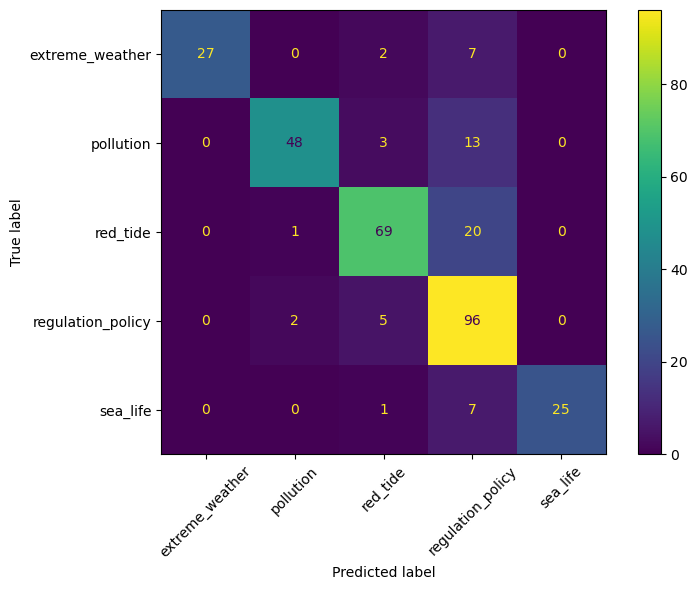

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    ax=ax,
    xticks_rotation=45)

plt.tight_layout()
plt.show()

## Zero-shot Transformer Classifier

In [27]:
from transformers import pipeline

In [28]:
import torch
#print(torch.cuda.is_available())

In [29]:
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [30]:
def zero_shot_predict(text):
    result = classifier(text, candidate_labels)
    return result['labels'][0]


In [31]:
candidate_labels = [
    'extreme_weather',
    'pollution',
    'red_tide',
    'regulation_policy',
    'sea_life']


In [33]:
# Run on test set - this will take a few minutes
start_time_zs = time.time()

zs_predictions = X_test.apply(zero_shot_predict)

end_time_zs = time.time()
process_time_zs = round(end_time_zs - start_time_zs, 2)
print(f"Training and testing zero-shot took: {process_time_zs}")

Training and testing zero-shot took: 220.52


### Accuracy and Confusion Matrix

In [34]:
print(f"Accuracy: {round(accuracy_score(y_test, zs_predictions), 4)}")
print(classification_report(y_test, zs_predictions))

Accuracy: 0.4172
                   precision    recall  f1-score   support

  extreme_weather       0.79      0.83      0.81        36
        pollution       0.67      0.58      0.62        64
         red_tide       0.32      0.29      0.30        90
regulation_policy       0.53      0.18      0.27       103
         sea_life       0.21      0.73      0.32        33

         accuracy                           0.42       326
        macro avg       0.50      0.52      0.47       326
     weighted avg       0.49      0.42      0.41       326



#### Confusion Matrix

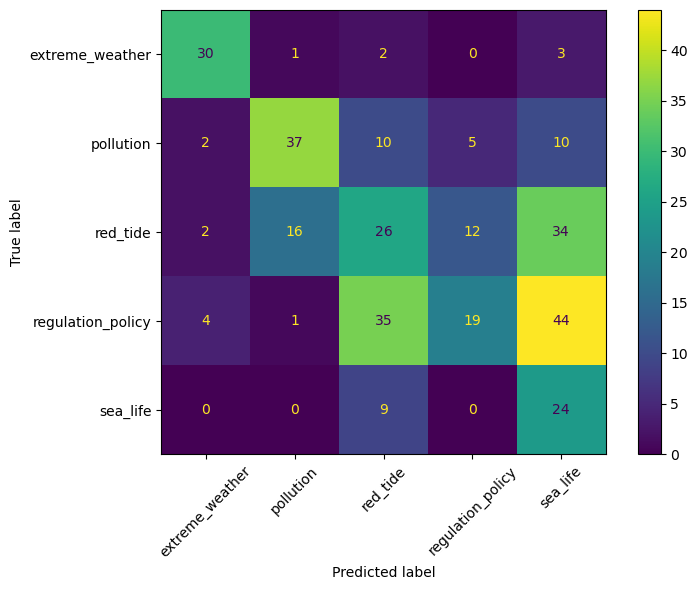

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    zs_predictions,
    ax=ax,
    xticks_rotation=45)

plt.tight_layout()
plt.show()

## MLflow Comparison

## Experiment Tracking with MLflow

Both runs are tracked using MLflow, allowing direct comparison of parameters 
and metrics. To view the experiment results, run `mlflow ui` from the project 
directory and open `http://localhost:5000`.

In [57]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, f1_score

In [58]:
# Set experiment name 
mlflow.set_experiment("coastal_newswatch")

2026/03/27 11:46:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/27 11:46:09 INFO mlflow.store.db.utils: Updating database tables
2026/03/27 11:46:10 INFO mlflow.tracking.fluent: Experiment with name 'coastal_newswatch' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/mpheng/Documents/DataAnalysis/coastal_newswatch_v2/mlruns/1', creation_time=1774608370229, experiment_id='1', last_update_time=1774608370229, lifecycle_stage='active', name='coastal_newswatch', tags={}, workspace='default'>

Log the SVM run

In [59]:
with mlflow.start_run(run_name="tfidf_svm"):
    # Log parameters
    mlflow.log_param("model", "SVM")
    mlflow.log_param("kernel", "linear")
    mlflow.log_param("text_features", "headlines")
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))

    # Log metrics
    mlflow.log_metric("accuracy", accuracy_score(y_test, predictions))
    mlflow.log_metric("f1_weighted", f1_score(y_test, predictions, average='weighted'))
    mlflow.log_metric("f1_macro", f1_score(y_test, predictions, average='macro'))

Log the zero-shot run

In [60]:
with mlflow.start_run(run_name="zero_shot_transformer"):
    mlflow.log_param("model", "facebook/bart-large-mnli")
    mlflow.log_param("approach", "zero-shot")
    mlflow.log_param("text_features", "headlines")
    mlflow.log_param("train_size", 0)
    mlflow.log_param("test_size", len(X_test))
    
    mlflow.log_metric("accuracy", accuracy_score(y_test, zs_predictions))
    mlflow.log_metric("f1_weighted", f1_score(y_test, zs_predictions, average='weighted'))
    mlflow.log_metric("f1_macro", f1_score(y_test, zs_predictions, average='macro'))

print("Run logged successful")

Run logged successful


## Conclusions

**Key findings:**

- TF-IDF + Linear SVM achieved **81.29% accuracy** on the test set, performing 
  competitively despite being trained on headline text only rather than full 
  article content
- Zero-shot classification using `facebook/bart-large-mnli` achieved **41.72% 
  accuracy** with no training data, confirming that domain-specific supervised 
  learning remains highly effective for specialised classification tasks
- The `regulation_policy` class — a merger of conservation and illegal fishing 
  articles — showed the lowest precision (0.67), suggesting these categories are 
  sufficiently distinct to warrant separation given adequate data
- Both runs are logged in MLflow, providing a reproducible record of parameters 
  and evaluation metrics

**Broader observation:**

The ~40 percentage point gap between supervised and zero-shot performance 
illustrates a consistent finding in NLP: for narrow, specialised domains with 
available labelled data, a well-tuned classical model trained on domain-specific 
text will outperform a general-purpose transformer applied zero-shot. This does 
not diminish the value of large language models, but highlights the continued 
relevance of supervised learning in applied data science contexts.